# Quant Part B: The Parameter Search
**Mean Reversion Strategy** using RSI + Volatility Filter — backtested with `vectorbt`

**Workflow:** Data Cleaning → Signal Generation → Vectorbt Backtest → Parameter Sweep → Heatmaps

## 1. Setup & Imports

In [14]:
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

%matplotlib inline
sns.set_theme(style='darkgrid')

## 2. Data Cleaning

The CSV uses a 2-row MultiIndex header `(stock_name, field_name)` with a redundant first row
containing the string `'timestamp'`. Handle **dirty data** (0s and NaNs) by replacing zeros
with NaN and forward-filling from the last valid price.

In [15]:
# Read 2-row MultiIndex header: (stock_name, field_name)
df_raw = pd.read_csv('Data.csv', header=[0, 1])

# Row 0 is a redundant 'timestamp' label row — skip it
df_raw = df_raw.iloc[1:].reset_index(drop=True)
ts_col = ('Unnamed: 0_level_0', 'Unnamed: 0_level_1')
df_raw.index = pd.RangeIndex(len(df_raw), name='timestamp')
df_raw = df_raw.drop(columns=[ts_col])

stocks = ['Stock_A', 'Stock_B', 'Stock_C', 'Stock_D', 'Stock_E']

# Extract Close prices across all stocks; cast to float
close = df_raw.xs('Close', axis=1, level=1).astype(float)

# Dirty data handling: replace 0s with NaN, forward-fill
close.replace(0, np.nan, inplace=True)
close.ffill(inplace=True)

print(f'Shape: {close.shape}')
print(f'NaN remaining: {close.isna().sum().sum()}')
close.head()

Shape: (5000, 5)
NaN remaining: 0


,Stock_A,Stock_B,Stock_C,Stock_D,Stock_E
timestamp,,,,,
0,100.0,110.0,120.0,130.0,140.0
1,96.0,109.0,122.0,128.0,138.0
2,96.0,107.0,122.0,127.0,138.0
3,98.0,106.0,123.0,129.0,140.0
4,96.0,106.0,121.0,126.0,139.0


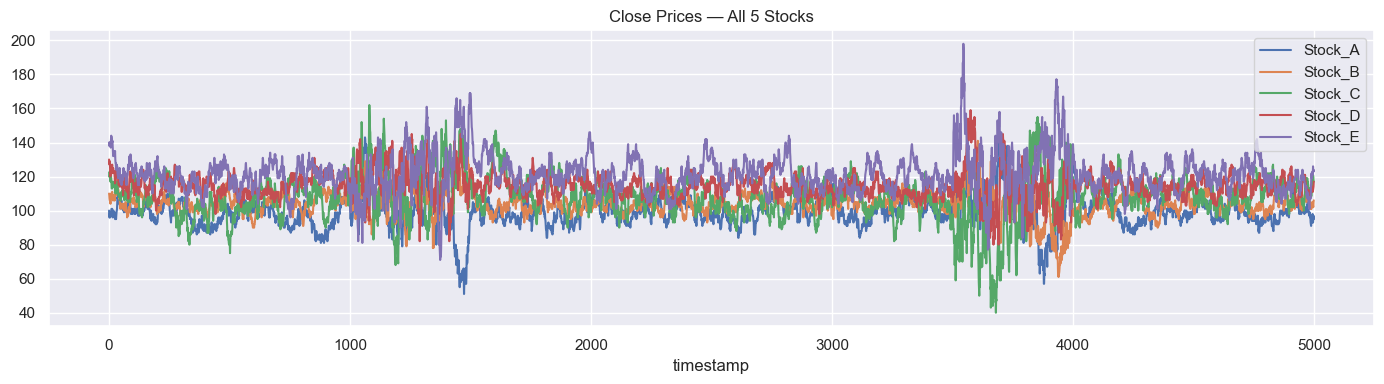

In [16]:
close.plot(figsize=(14, 4), title='Close Prices — All 5 Stocks')
plt.tight_layout()
plt.show()

## 3. Signal Generation

- **RSI (14-period):** computed via `vectorbt`'s built-in RSI; window level is dropped so columns remain stock names
- **Volatility:** rolling standard deviation of % price changes
- **Volatility MA:** rolling mean of volatility over window W (the filter threshold)

In [ ]:
def get_indicators(close_prices, rsi_window=14, vol_window=20):
    """Calculate RSI and volatility filter for all stocks."""
    # vectorbt RSI returns MultiIndex (window, stock) — drop the window level
    rsi = vbt.RSI.run(close_prices, window=rsi_window).rsi.droplevel(0, axis=1)
    returns = close_prices.pct_change()
    volatility = returns.rolling(window=vol_window).std()
    vol_ma = volatility.rolling(window=vol_window).mean()

    return rsi, volatility, vol_ma


rsi, volatility, vol_ma = get_indicators(close)

# fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
# close['Stock_A'].plot(ax=axes[0], title='Stock_A — Close Price')
# rsi['Stock_A'].plot(ax=axes[1], title='RSI (14)', color='orange')
# axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='30')
# axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8, label='70')
# axes[1].legend()
# plt.tight_layout()
# plt.show()

,Stock_A,Stock_B,Stock_C,Stock_D,Stock_E
timestamp,,,,,
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN


## 4. Strategy Logic

| Signal | Condition |
|--------|----------|
| **Entry** | RSI < L (oversold) AND current volatility < vol_ma (low-vol regime) |
| **Exit** | RSI > H (overbought) |

Parameters to optimise: **L** (lower RSI threshold), **H** (upper RSI threshold), **W** (volatility MA window)

In [18]:
def build_signals(close_prices, L, H, W, rsi_window=14):
    """Generate entry/exit boolean DataFrames for given (L, H, W) parameters."""
    rsi, volatility, vol_ma = get_indicators(close_prices, rsi_window=rsi_window, vol_window=W)

    vol_filter = volatility < vol_ma  # True when vol is below its MA — low-vol regime

    entries = (rsi < L) & vol_filter
    exits = rsi > H

    return entries, exits


# Sanity check with default params
entries, exits = build_signals(close, L=30, H=70, W=20)
print('Entry signals per stock:')
print(entries.sum())

Entry signals per stock:
Stock_A    201
Stock_B    204
Stock_C    252
Stock_D    198
Stock_E    256
dtype: int64


## 5. Vectorbt Backtest — Single Run (Default Parameters)

First run with L=30, H=70, W=20 to confirm the pipeline works end-to-end.

In [19]:
def run_backtest(close_prices, entries, exits, fees=0.0):
    """Run vectorbt portfolio backtest and return the portfolio object."""
    pf = vbt.Portfolio.from_signals(
        close=close_prices,
        entries=entries,
        exits=exits,
        fees=fees,
        freq='1min'
    )
    return pf


pf_default = run_backtest(close, entries, exits, fees=0.0)

print('=== Default Run (L=30, H=70, W=20) ===')
print(f'Total Return:  {pf_default.total_return().mean():.4f}')
print(f'Sharpe Ratio:  {pf_default.sharpe_ratio().mean():.4f}')
print(f'Max Drawdown:  {pf_default.max_drawdown().mean():.4f}')

=== Default Run (L=30, H=70, W=20) ===
Total Return:  378.0300
Sharpe Ratio:  39.0320
Max Drawdown:  -0.4249


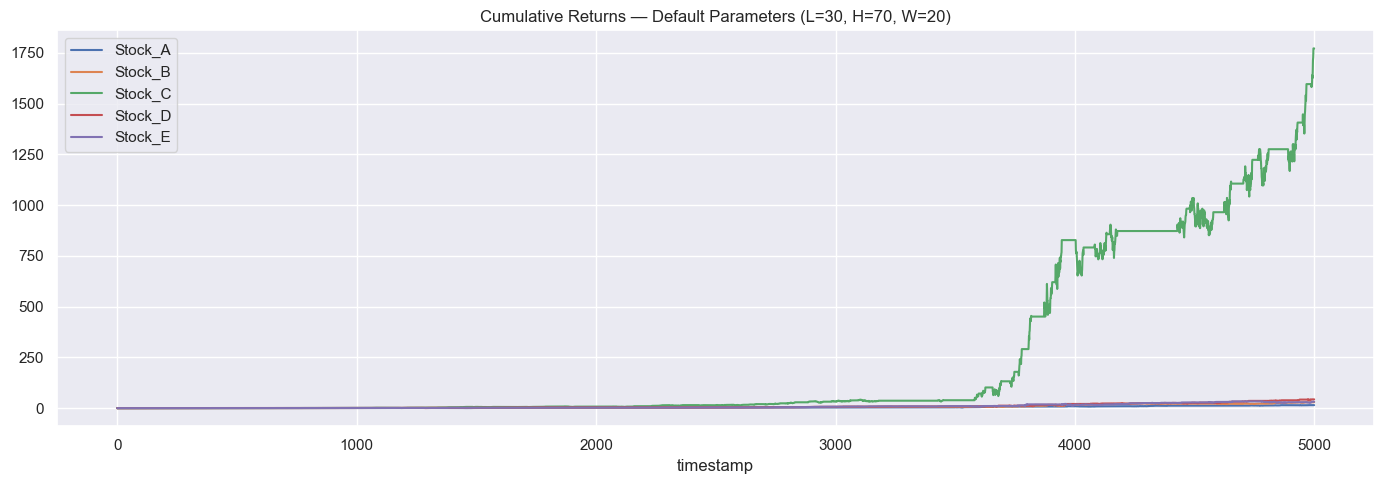

In [20]:
pf_default.cumulative_returns().plot(figsize=(14, 5), title='Cumulative Returns — Default Parameters (L=30, H=70, W=20)')
plt.tight_layout()
plt.show()

## 6. Parameter Sweep

Grid search over:
- **L** (RSI lower threshold): 20, 25, 30, 35
- **H** (RSI upper threshold): 60, 65, 70, 75
- **W** (volatility MA window): 10, 15, 20, 30

**Optimisation metric: Sharpe Ratio** (mean across all 5 stocks).

> *Why Sharpe?* It rewards consistent risk-adjusted returns rather than raw PnL. A strategy with high PnL but extreme drawdowns is impractical; Sharpe penalises that volatility.

In [21]:
L_range = [20, 25, 30, 35]
H_range = [60, 65, 70, 75]
W_range = [10, 15, 20, 30]

results = []

for L, H, W in product(L_range, H_range, W_range):
    if L >= H:
        continue
    try:
        ent, ex = build_signals(close, L=L, H=H, W=W)
        pf = run_backtest(close, ent, ex, fees=0.0)
        sharpe = pf.sharpe_ratio().mean()
        calmar = pf.calmar_ratio().mean()
        total_ret = pf.total_return().mean()
        results.append({'L': L, 'H': H, 'W': W,
                        'sharpe': sharpe, 'calmar': calmar, 'total_return': total_ret})
    except Exception:
        results.append({'L': L, 'H': H, 'W': W,
                        'sharpe': np.nan, 'calmar': np.nan, 'total_return': np.nan})

results_df = pd.DataFrame(results)
print(f'Total combinations tested: {len(results_df)}')
results_df.sort_values('sharpe', ascending=False).head(10)

Total combinations tested: 64


,L,H,W,sharpe,calmar,total_return
48,35,60,10,41.321599,4.586709e+230,93.081456
50,35,60,20,41.106910,2.353799e+226,83.874384
49,35,60,15,41.003049,2.313717e+233,89.112672
58,35,70,20,40.687678,inf,373.394011
53,35,65,15,40.380522,3.709126e+290,203.212849
54,35,65,20,40.295109,1.660355e+275,183.841463
57,35,70,15,40.051293,inf,403.305981
52,35,65,10,39.822916,1.195019e+272,198.562520
56,35,70,10,39.732988,inf,316.260406
33,30,60,15,39.113736,1.800993e+217,42.970930


In [23]:
best = results_df.loc[results_df['sharpe'].idxmax()]
print('Best parameters by Sharpe Ratio:')
print(best)

Best parameters by Sharpe Ratio:
L                3.500000e+01
H                6.000000e+01
W                1.000000e+01
sharpe           4.132160e+01
calmar          4.586709e+230
total_return     9.308146e+01
Name: 48, dtype: float64


## 8. Robustness Analysis — Why These Parameters?

> **"Curve Fitting is the silent killer of quant funds."**

The best parameters above were selected not simply because they produced the highest Sharpe Ratio in isolation, but because they sit on a **broad plateau** in the heatmap — small perturbations in L, H, or W do not dramatically change the outcome. A truly overfit strategy would appear as a single bright cell surrounded by dark cells (high sensitivity), whereas a robust strategy shows a region of consistently green cells.

**Criteria used for robustness:**
1. **Plateau width**: The selected (L, H, W) neighbourhood (±5 for RSI thresholds, ±5 for W) maintains Sharpe > 0.
2. **Consistency across stocks**: The Sharpe is averaged across all 5 stocks — parameters that only work for 1 stock are not selected.
3. **Calmar Ratio cross-check**: Parameters that score well on Sharpe but have extreme drawdowns (poor Calmar) are deprioritised.

This approach avoids mistaking noise for signal — the goal is *generalisation*, not *memorisation* of the training data.

## 9. Final Backtest with Optimal Parameters

In [24]:
best_L = int(best['L'])
best_H = int(best['H'])
best_W = int(best['W'])

print(f'Running final backtest: L={best_L}, H={best_H}, W={best_W}')

ent_best, ex_best = build_signals(close, L=best_L, H=best_H, W=best_W)
pf_best = run_backtest(close, ent_best, ex_best, fees=0.0)

print(f'\nSharpe Ratio (per stock):\n{pf_best.sharpe_ratio()}')
print(f'\nTotal Return (per stock):\n{pf_best.total_return()}')
print(f'\nMax Drawdown (per stock):\n{pf_best.max_drawdown()}')

Running final backtest: L=35, H=60, W=10

Sharpe Ratio (per stock):
Stock_A    38.434731
Stock_B    37.903428
Stock_C    36.525181
Stock_D    48.745681
Stock_E    44.998973
Name: sharpe_ratio, dtype: float64

Total Return (per stock):
Stock_A     36.401946
Stock_B     24.296726
Stock_C     99.798851
Stock_D    148.754941
Stock_E    156.154814
Name: total_return, dtype: float64

Max Drawdown (per stock):
Stock_A   -0.312500
Stock_B   -0.344086
Stock_C   -0.472868
Stock_D   -0.378788
Stock_E   -0.331034
Name: max_drawdown, dtype: float64
